In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go

In [2]:
############ customization
length = 24
width = 24
n1 = 9
n2 = 7
judge = 0


In [3]:
## grid generation
def generate_rectangular_grid(length, width, n1, n2=2, judge=0, z=0, height=0):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for x in x_points:
        for y in y_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

[[0.0, 24.0, 0], [0.0, 20.57142857142857, 0], [0.0, 17.142857142857142, 0], [0.0, 13.714285714285714, 0], [0.0, 10.285714285714285, 0], [0.0, 6.857142857142857, 0], [0.0, 3.4285714285714284, 0], [0.0, 0.0, 0], [2.6666666666666665, 24.0, 0], [2.6666666666666665, 20.57142857142857, 0], [2.6666666666666665, 17.142857142857142, 0], [2.6666666666666665, 13.714285714285714, 0], [2.6666666666666665, 10.285714285714285, 0], [2.6666666666666665, 6.857142857142857, 0], [2.6666666666666665, 3.4285714285714284, 0], [2.6666666666666665, 0.0, 0], [5.333333333333333, 24.0, 0], [5.333333333333333, 20.57142857142857, 0], [5.333333333333333, 17.142857142857142, 0], [5.333333333333333, 13.714285714285714, 0], [5.333333333333333, 10.285714285714285, 0], [5.333333333333333, 6.857142857142857, 0], [5.333333333333333, 3.4285714285714284, 0], [5.333333333333333, 0.0, 0], [8.0, 24.0, 0], [8.0, 20.57142857142857, 0], [8.0, 17.142857142857142, 0], [8.0, 13.714285714285714, 0], [8.0, 10.285714285714285, 0], [8.0,

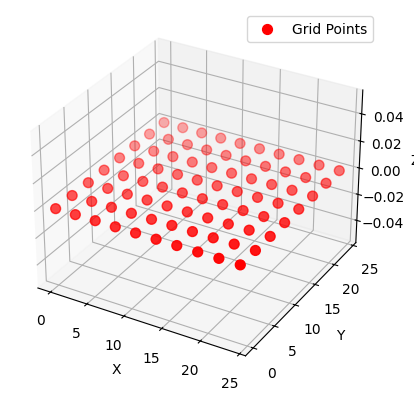

In [4]:
grid_points = generate_rectangular_grid(length, width, n1, n2, judge)
connectivity = generate_connectivity_matrix(grid_points)
print(grid_points)
print(connectivity)
plot_grid(grid_points,length,width)

In [5]:
############# Problem context
n_dof_per_node = 6  # Degrees of freedom per node
total_dof = n_dof_per_node * len(grid_points)
grid_points = torch.tensor(grid_points)
########## Surrounding fixed
x_max = grid_points[:, 0].max()
x_min = grid_points[:, 0].min()
y_max = grid_points[:, 1].max()
y_min = grid_points[:, 1].min()
Fixed_nodes = torch.where(
#     (grid_points[:, 0] == x_max) |  # x = x_max
#     (grid_points[:, 0] == x_min) |  # x = x_min
    (grid_points[:, 1] == y_max) |  # y = y_max
    (grid_points[:, 1] == y_min)    # y = y_min
)[0]

Fixed_nodes += 1
Free_nodes = []
n_elements = len(connectivity)
n_nodes = len(grid_points)
for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)

F = torch.zeros(total_dof, dtype=torch.float32)
f_n = Free_nodes
f_type = [2] * len(Free_nodes)  # The force type
F_value = torch.tensor([-50.0] * len(Free_nodes)) * 100 # The force value/direction

r = 1 / torch.max(F_value)

F_sign = torch.sign(F_value)
for idx, i in enumerate(f_n):
    F[6 * (i - 1) + f_type[idx]] = F_value[idx]  # unit: KN / KN*m

####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])

print(Free_nodes)

idx_Fixed = torch.tensor(Fixed_nodes) - 1
idx_Free = torch.tensor(Free_nodes) - 1 

[2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 34, 35, 36, 37, 38, 39, 42, 43, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 58, 59, 60, 61, 62, 63, 66, 67, 68, 69, 70, 71, 74, 75, 76, 77, 78, 79]


/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_18659/3277945681.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  idx_Fixed = torch.tensor(Fixed_nodes) - 1


In [6]:

def find_connectivity_indices(grid_points, connectivity, free_nodes):
    
    grid_points = torch.tensor(grid_points, dtype=torch.float32)
    
    connectivity = torch.tensor(connectivity, dtype=torch.long)
    
    free_nodes = torch.tensor(free_nodes, dtype=torch.long)
    
    result_indices_x = []  
    result_indices_y = []  
    
    prev_x_list = []  
    prev_y_list = []  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1] 
        x = node_coord[0]

        if x in prev_x_list:
            x_index = prev_x_list.index(x)
        else:
            result_indices_x.append([])
            prev_x_list.append(x)
            x_index = len(prev_x_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        candidate_indices = torch.where(mask)[0] # indexing connectivity
        
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]

            if coord1[0] == coord2[0] and coord1[0] == x:
                result_indices_x[x_index].append(idx.item())  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1]  
        y = node_coord[1]
        
        if y in prev_y_list:
            y_index = prev_y_list.index(y)
        else:
            result_indices_y.append([])
            prev_y_list.append(y)
            y_index = len(prev_y_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        candidate_indices = torch.where(mask)[0]
           
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]
            if coord1[1] == coord2[1] and coord1[1] == y:
                result_indices_y[y_index].append(idx.item()) 

    print(" x unorganized：", result_indices_x)
    print(" y unorganized：", result_indices_y)
    
    
    max_len_x = max(len(indices) for indices in result_indices_x) if result_indices_x else 0
    max_len_y = max(len(indices) for indices in result_indices_y) if result_indices_y else 0
    
    
    for indices in result_indices_x:
        indices += [-1] * (max_len_x - len(indices))
    for indices in result_indices_y:
        indices += [-1] * (max_len_y - len(indices))
    
    
    result_x = torch.tensor(result_indices_x, dtype=torch.long)
    result_y = torch.tensor(result_indices_y, dtype=torch.long)
    result_x = torch.unique(result_x, dim=1)
    result_y = torch.unique(result_y, dim=1)
    return result_x, result_y

idx_X, idx_Y = find_connectivity_indices(grid_points, connectivity, Free_nodes)
print("x indices：")
print(idx_X)
print("y indices：")
print(idx_Y)

 x unorganized： [[0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6], [7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13], [14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 20], [21, 22, 22, 23, 23, 24, 24, 25, 25, 26, 26, 27], [28, 29, 29, 30, 30, 31, 31, 32, 32, 33, 33, 34], [35, 36, 36, 37, 37, 38, 38, 39, 39, 40, 40, 41], [42, 43, 43, 44, 44, 45, 45, 46, 46, 47, 47, 48], [49, 50, 50, 51, 51, 52, 52, 53, 53, 54, 54, 55], [56, 57, 57, 58, 58, 59, 59, 60, 60, 61, 61, 62], [63, 64, 64, 65, 65, 66, 66, 67, 67, 68, 68, 69]]
 y unorganized： [[124, 124, 125, 125, 126, 126, 127, 127, 128, 128, 129, 129, 130, 130, 131, 131, 132, 132], [115, 115, 116, 116, 117, 117, 118, 118, 119, 119, 120, 120, 121, 121, 122, 122, 123, 123], [106, 106, 107, 107, 108, 108, 109, 109, 110, 110, 111, 111, 112, 112, 113, 113, 114, 114], [97, 97, 98, 98, 99, 99, 100, 100, 101, 101, 102, 102, 103, 103, 104, 104, 105, 105], [88, 88, 89, 89, 90, 90, 91, 91, 92, 92, 93, 93, 94, 94, 95, 95, 96, 96], [79, 79, 80, 80, 81, 81, 82, 82, 83, 83, 84, 84

/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_18659/3458792347.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  grid_points = torch.tensor(grid_points, dtype=torch.float32)


In [7]:
####### Symetry reshaper -- quires even numbers of indices
len_y = idx_Y.size(0)
half_y = len_y // 2
len_x = idx_X.size(0)
half_x = len_x // 2

y_upper = idx_Y[:half_y]  
y_lower = idx_Y[half_y:] 
y_lower = torch.flip(y_lower, dims=[0])
x_upper = idx_X[:half_x]  
x_lower = idx_X[half_x:]  
x_lower = torch.flip(x_lower, dims=[0])


idx_Y = torch.cat((y_upper, y_lower), dim=1)
idx_X = torch.cat((x_upper, x_lower), dim=1)   

print("Recomposed Y mat:")
print(idx_Y)
print("Recomposed X mat:")
print(idx_X)

Recomposed Y mat:
tensor([[124, 125, 126, 127, 128, 129, 130, 131, 132,  79,  80,  81,  82,  83,
          84,  85,  86,  87],
        [115, 116, 117, 118, 119, 120, 121, 122, 123,  88,  89,  90,  91,  92,
          93,  94,  95,  96],
        [106, 107, 108, 109, 110, 111, 112, 113, 114,  97,  98,  99, 100, 101,
         102, 103, 104, 105]])
Recomposed X mat:
tensor([[ 0,  1,  2,  3,  4,  5,  6, 63, 64, 65, 66, 67, 68, 69],
        [ 7,  8,  9, 10, 11, 12, 13, 56, 57, 58, 59, 60, 61, 62],
        [14, 15, 16, 17, 18, 19, 20, 49, 50, 51, 52, 53, 54, 55],
        [21, 22, 23, 24, 25, 26, 27, 42, 43, 44, 45, 46, 47, 48],
        [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]])


In [8]:
n1_ = 9
n2_ = 2
n_ = 6

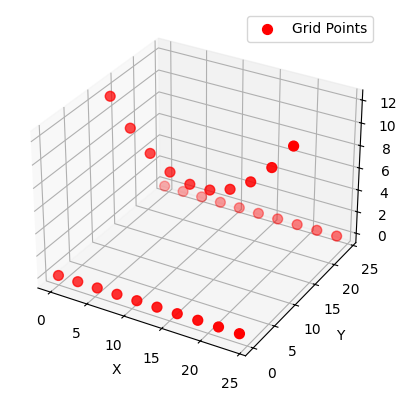

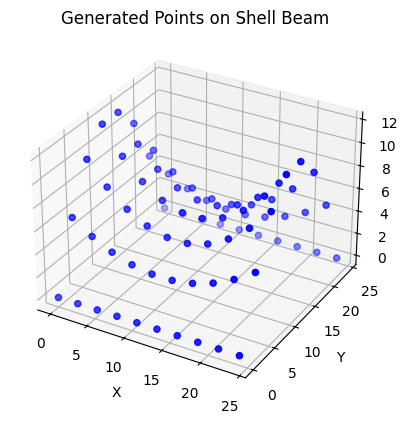

tensor([[ 0.0000e+00,  2.4000e+01,  2.8422e-14],
        [ 0.0000e+00,  2.0571e+01,  5.8776e+00],
        [ 0.0000e+00,  1.7143e+01,  9.7959e+00],
        [ 0.0000e+00,  1.3714e+01,  1.1755e+01],
        [ 0.0000e+00,  1.0286e+01,  1.1755e+01],
        [ 0.0000e+00,  6.8571e+00,  9.7959e+00],
        [ 0.0000e+00,  3.4286e+00,  5.8776e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 2.6667e+00,  2.4000e+01,  1.7214e-14],
        [ 2.6667e+00,  2.0571e+01,  4.7398e+00],
        [ 2.6667e+00,  1.7143e+01,  7.8996e+00],
        [ 2.6667e+00,  1.3714e+01,  9.4795e+00],
        [ 2.6667e+00,  1.0286e+01,  9.4795e+00],
        [ 2.6667e+00,  6.8571e+00,  7.8996e+00],
        [ 2.6667e+00,  3.4286e+00,  4.7398e+00],
        [ 2.6667e+00,  0.0000e+00, -4.1023e-15],
        [ 5.3333e+00,  2.4000e+01,  1.0109e-14],
        [ 5.3333e+00,  2.0571e+01,  3.8864e+00],
        [ 5.3333e+00,  1.7143e+01,  6.4774e+00],
        [ 5.3333e+00,  1.3714e+01,  7.7729e+00],
        [ 5.3333e+00

In [9]:
### This part is for obtaining the Target geometry:
###############################
######### THis is for double curvatures

def generate_rectangular_grid_db(length, width, n1, n2=2, judge=0, z=0, Max_height=12, Min_height=6.12):
    x_ori = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]
    
    x_values = [0, length/2, length]
    z_values = [Max_height, Min_height ,Max_height]
    
    coefficients = np.polyfit(x_values, z_values, 2)
    a, b, c = coefficients
    x_points = np.linspace(min(x_ori), max(x_ori), n1 + 1)
    height = a * x_points**2 + b * x_points + c

    grid_points = []
    for y in y_points:
        for idx, x in enumerate(x_points):
            if y == width / 2:
                grid_points.append([x, y, height[idx]])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def add_points(node_coords_db, n):
    node_coords = node_coords_db.numpy()
    x_values = np.unique(node_coords[:, 0])
    new_coords = []

    for x in x_values:
        points_on_line = node_coords[node_coords[:, 0] == x]
        y_values = points_on_line[:, 1]
        z_values = points_on_line[:, 2]
        coefficients = np.polyfit(y_values, z_values, 2)
        a, b, c = coefficients
        y_new = np.linspace(max(y_values), min(y_values), n + 2)
        z_new = a * y_new**2 + b * y_new + c

        for y, z in zip(y_new, z_new):
            new_coords.append([x, y, z])

    new_coords = torch.tensor(new_coords, dtype=torch.float32)
    return new_coords

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points_db = generate_rectangular_grid_db(length, width, n1_)

node_coords_db = torch.tensor(grid_points_db)

new_coords_db = add_points(node_coords_db, n_)

new_coords_db = new_coords_db.tolist()

new_coords_db = torch.tensor(new_coords_db, dtype=torch.float32)

############## plotting

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()


def plot_points(points):
    if isinstance(points, list):
        points = torch.tensor(points, dtype=torch.float32)
    points = points.numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    ax.scatter(x, y, z, c='b', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Generated Points on Shell Beam')
    plt.show()


plot_grid(grid_points_db,length,width)
plot_points(new_coords_db)

print(new_coords_db)

#######################################
# ### For single curvature
# def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, height=6):
#     x_points = [i * (length / n1) for i in range(n1 + 1)]
#     y_points = [j * (width / n2) for j in range(n2, -1, -1)]

#     grid_points = []
#     for y in y_points:
#         for x in x_points:
#             if y == width / 2:
#                 grid_points.append([x, y, height])
#             else:
#                 grid_points.append([x, y, z])

#     if judge == 1:
#         corners = [
#             [x_points[0], y_points[0], z],
#             [x_points[0], y_points[-1], z],
#             [x_points[-1], y_points[0], z],
#             [x_points[-1], y_points[-1], z]
#         ]
#         grid_points = [point for point in grid_points if point not in corners]

#     return grid_points

# def add_points(node_coords_sg, n):
#     node_coords = node_coords_sg.numpy()
#     x_values = np.unique(node_coords[:, 0])
#     new_coords = []

#     for x in x_values:
#         points_on_line = node_coords[node_coords[:, 0] == x]
#         y_values = points_on_line[:, 1]
#         z_values = points_on_line[:, 2]
#         coefficients = np.polyfit(y_values, z_values, 2)
#         a, b, c = coefficients
#         y_new = np.linspace(max(y_values), min(y_values), n + 2)
#         z_new = a * y_new**2 + b * y_new + c

#         for y, z in zip(y_new, z_new):
#             new_coords.append([x, y, z])

#     new_coords = torch.tensor(new_coords, dtype=torch.float32)
#     return new_coords

# def generate_connectivity_matrix(new_coords):

#     indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

#     connectivity = []


#     x_values = sorted(set(point[0] for point in new_coords))
#     for x in x_values:

#         points_on_line = [point for point in new_coords if point[0] == x]
#         points_on_line.sort(key=lambda p: p[1], reverse=True) 


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])


#     y_values = sorted(set(point[1] for point in new_coords))
#     for y in y_values:
       
#         points_on_line = [point for point in new_coords if point[1] == y]
#         points_on_line.sort(key=lambda p: p[0])  


#         for i in range(len(points_on_line) - 1):
#             node1 = indexed_points[tuple(points_on_line[i])]
#             node2 = indexed_points[tuple(points_on_line[i + 1])]
#             connectivity.append([node1, node2])

#     return connectivity

# grid_points_sg = generate_rectangular_grid_sg(length, width, n1, n2, judge)

# node_coords_sg = torch.tensor(grid_points_sg)

# new_coords_sg = add_points(node_coords_sg, n)

# new_coords_sg = new_coords_sg.tolist()

# connectivity_sg = generate_connectivity_matrix(new_coords_sg)

# new_coords_sg = torch.tensor(new_coords_sg, dtype=torch.float32)
# ############## plotting

# def plot_grid(grid_points, length, width):
#     x = [point[0] for point in grid_points]
#     y = [point[1] for point in grid_points]
#     z = [point[2] for point in grid_points]

#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.legend()
#     plt.show()


# def plot_points(points):
#     if isinstance(points, list):
#         points = torch.tensor(points, dtype=torch.float32)
#     points = points.numpy()
#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     x = points[:, 0]
#     y = points[:, 1]
#     z = points[:, 2]
#     ax.scatter(x, y, z, c='b', marker='o')
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.set_title('Generated Points on Shell Beam')
#     plt.show()


# plot_grid(grid_points_sg,length,width)
# plot_points(new_coords_sg)

print(new_coords_db.shape)

In [10]:
#######

# Redefine the OBJ:
Obj_coords = new_coords_db[idx_Free][:, 2]
print(Obj_coords)
print(idx_Free)

tensor([ 5.8776,  9.7959, 11.7551, 11.7551,  9.7959,  5.8776,  4.7398,  7.8996,
         9.4795,  9.4795,  7.8996,  4.7398,  3.8864,  6.4774,  7.7729,  7.7729,
         6.4774,  3.8864,  3.3176,  5.5293,  6.6351,  6.6351,  5.5293,  3.3176,
         3.0331,  5.0552,  6.0662,  6.0662,  5.0552,  3.0331,  3.0331,  5.0552,
         6.0662,  6.0662,  5.0552,  3.0331,  3.3176,  5.5293,  6.6351,  6.6351,
         5.5293,  3.3176,  3.8864,  6.4774,  7.7729,  7.7729,  6.4774,  3.8864,
         4.7398,  7.8996,  9.4795,  9.4795,  7.8996,  4.7398,  5.8776,  9.7959,
        11.7551, 11.7551,  9.7959,  5.8776])
tensor([ 1,  2,  3,  4,  5,  6,  9, 10, 11, 12, 13, 14, 17, 18, 19, 20, 21, 22,
        25, 26, 27, 28, 29, 30, 33, 34, 35, 36, 37, 38, 41, 42, 43, 44, 45, 46,
        49, 50, 51, 52, 53, 54, 57, 58, 59, 60, 61, 62, 65, 66, 67, 68, 69, 70,
        73, 74, 75, 76, 77, 78])


In [14]:
####### Gradient descent
step = 0.005
epochs = 800

0
tensor([ 0.0000,  3.4318,  4.6042,  5.2503,  5.2503,  4.6042,  3.4318,  0.0000,
         2.6667,  4.8621,  5.7411,  6.2434,  6.2434,  5.7411,  4.8621,  2.6667,
         5.3333,  6.6157,  7.1938,  7.5361,  7.5361,  7.1938,  6.6157,  5.3333,
         8.0000,  8.6658,  8.9856,  9.1789,  9.1789,  8.9856,  8.6658,  8.0000,
        10.6667, 10.8620, 10.9599, 11.0199, 11.0199, 10.9599, 10.8620, 10.6667,
        13.3333, 13.1380, 13.0401, 12.9801, 12.9801, 13.0401, 13.1380, 13.3333,
        16.0000, 15.3342, 15.0144, 14.8211, 14.8211, 15.0144, 15.3342, 16.0000,
        18.6667, 17.3843, 16.8062, 16.4639, 16.4639, 16.8062, 17.3843, 18.6667,
        21.3333, 19.1379, 18.2589, 17.7566, 17.7566, 18.2589, 19.1379, 21.3333,
        24.0000, 20.5682, 19.3958, 18.7497, 18.7497, 19.3958, 20.5682, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 0: Normalized Gradient = 9.493294715881348, Adaptive learning rate = 0.005
1
tensor([ 0.0000,  3.4278,  4.6048,  5.2519,  5.2519,  4.6048,  3.4278,  0.00

tensor([ 0.0000,  3.3940,  4.6083,  5.2628,  5.2628,  4.6083,  3.3940,  0.0000,
         2.6667,  4.8135,  5.7211,  6.2301,  6.2301,  5.7211,  4.8135,  2.6667,
         5.3333,  6.5835,  7.1782,  7.5243,  7.5243,  7.1782,  6.5835,  5.3333,
         8.0000,  8.6484,  8.9767,  9.1719,  9.1719,  8.9767,  8.6484,  8.0000,
        10.6667, 10.8579, 10.9586, 11.0193, 11.0193, 10.9586, 10.8579, 10.6667,
        13.3333, 13.1421, 13.0414, 12.9807, 12.9807, 13.0414, 13.1421, 13.3333,
        16.0000, 15.3516, 15.0233, 14.8281, 14.8281, 15.0233, 15.3516, 16.0000,
        18.6667, 17.4165, 16.8218, 16.4757, 16.4757, 16.8218, 17.4165, 18.6667,
        21.3333, 19.1866, 18.2789, 17.7699, 17.7699, 18.2789, 19.1865, 21.3333,
        24.0000, 20.6060, 19.3917, 18.7372, 18.7372, 19.3917, 20.6060, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 10: Normalized Gradient = 4.69697904586792, Adaptive learning rate = 0.005
11
tensor([ 0.0000,  3.3915,  4.6097,  5.2650,  5.2650,  4.6097,  3.3915,  0.000

tensor([ 0.0000,  3.3854,  4.6373,  5.2990,  5.2990,  4.6373,  3.3854,  0.0000,
         2.6667,  4.7914,  5.7254,  6.2405,  6.2405,  5.7254,  4.7914,  2.6667,
         5.3333,  6.5675,  7.1778,  7.5275,  7.5275,  7.1778,  6.5675,  5.3333,
         8.0000,  8.6394,  8.9756,  9.1726,  9.1726,  8.9756,  8.6394,  8.0000,
        10.6667, 10.8558, 10.9591, 11.0205, 11.0205, 10.9591, 10.8558, 10.6667,
        13.3333, 13.1442, 13.0409, 12.9795, 12.9795, 13.0409, 13.1442, 13.3333,
        16.0000, 15.3606, 15.0244, 14.8274, 14.8274, 15.0244, 15.3606, 16.0000,
        18.6667, 17.4325, 16.8222, 16.4725, 16.4725, 16.8222, 17.4325, 18.6667,
        21.3333, 19.2086, 18.2746, 17.7595, 17.7595, 18.2746, 19.2086, 21.3333,
        24.0000, 20.6146, 19.3627, 18.7010, 18.7010, 19.3627, 20.6146, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 20: Normalized Gradient = 4.005642414093018, Adaptive learning rate = 0.005
21
tensor([ 0.0000,  3.3855,  4.6408,  5.3031,  5.3031,  4.6408,  3.3855,  0.00

tensor([ 0.0000,  3.3853,  4.6657,  5.3316,  5.3316,  4.6657,  3.3853,  0.0000,
         2.6667,  4.7777,  5.7314,  6.2501,  6.2501,  5.7314,  4.7777,  2.6667,
         5.3333,  6.5559,  7.1773,  7.5290,  7.5290,  7.1773,  6.5559,  5.3333,
         8.0000,  8.6321,  8.9737,  9.1715,  9.1715,  8.9737,  8.6321,  8.0000,
        10.6667, 10.8540, 10.9589, 11.0206, 11.0206, 10.9589, 10.8540, 10.6667,
        13.3333, 13.1460, 13.0411, 12.9794, 12.9794, 13.0411, 13.1460, 13.3333,
        16.0000, 15.3679, 15.0263, 14.8285, 14.8285, 15.0263, 15.3679, 16.0000,
        18.6667, 17.4441, 16.8227, 16.4710, 16.4710, 16.8227, 17.4441, 18.6667,
        21.3333, 19.2223, 18.2686, 17.7499, 17.7499, 18.2686, 19.2223, 21.3333,
        24.0000, 20.6147, 19.3343, 18.6684, 18.6684, 19.3343, 20.6147, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 30: Normalized Gradient = 3.5204012393951416, Adaptive learning rate = 0.005
31
tensor([ 0.0000,  3.3849,  4.6676,  5.3337,  5.3337,  4.6676,  3.3849,  0.0

tensor([ 0.0000,  3.3767,  4.6739,  5.3399,  5.3399,  4.6739,  3.3767,  0.0000,
         2.6667,  4.7587,  5.7228,  6.2414,  6.2414,  5.7228,  4.7587,  2.6667,
         5.3333,  6.5403,  7.1662,  7.5170,  7.5170,  7.1662,  6.5403,  5.3333,
         8.0000,  8.6224,  8.9655,  9.1623,  9.1623,  8.9655,  8.6224,  8.0000,
        10.6667, 10.8512, 10.9566, 11.0179, 11.0179, 10.9565, 10.8512, 10.6667,
        13.3333, 13.1488, 13.0435, 12.9821, 12.9821, 13.0434, 13.1488, 13.3333,
        16.0000, 15.3776, 15.0345, 14.8377, 14.8377, 15.0345, 15.3776, 16.0000,
        18.6667, 17.4597, 16.8338, 16.4830, 16.4830, 16.8338, 17.4597, 18.6667,
        21.3333, 19.2413, 18.2772, 17.7586, 17.7586, 18.2772, 19.2413, 21.3333,
        24.0000, 20.6233, 19.3261, 18.6601, 18.6601, 19.3261, 20.6233, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 40: Normalized Gradient = 3.1479604244232178, Adaptive learning rate = 0.005
41
tensor([ 0.0000,  3.3752,  4.6735,  5.3393,  5.3393,  4.6735,  3.3752,  0.0

...

tensor([ 0.0000,  2.4354,  3.4100,  3.8044,  3.8044,  3.4100,  2.4354,  0.0000,
         2.6667,  3.6571,  4.2103,  4.4621,  4.4621,  4.2103,  3.6571,  2.6667,
         5.3333,  5.7277,  5.9751,  6.0942,  6.0942,  5.9751,  5.7277,  5.3333,
         8.0000,  8.1455,  8.2406,  8.2873,  8.2873,  8.2406,  8.1455,  8.0000,
        10.6667, 10.7028, 10.7268, 10.7386, 10.7386, 10.7268, 10.7028, 10.6667,
        13.3333, 13.2972, 13.2732, 13.2614, 13.2614, 13.2732, 13.2972, 13.3333,
        16.0000, 15.8545, 15.7594, 15.7127, 15.7127, 15.7594, 15.8545, 16.0000,
        18.6667, 18.2723, 18.0249, 17.9058, 17.9058, 18.0249, 18.2723, 18.6667,
        21.3333, 20.3429, 19.7897, 19.5379, 19.5379, 19.7897, 20.3429, 21.3333,
        24.0000, 21.5646, 20.5900, 20.1956, 20.1956, 20.5900, 21.5646, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 760: Normalized Gradient = 3.2967047691345215, Adaptive learning rate = 0.005
761
tensor([ 0.0000,  2.4301,  3.4011,  3.7937,  3.7937,  3.4011,  2.4301,  0

tensor([ 0.0000,  2.4310,  3.4026,  3.7949,  3.7949,  3.4025,  2.4310,  0.0000,
         2.6667,  3.6536,  4.2041,  4.4541,  4.4541,  4.2041,  3.6536,  2.6667,
         5.3333,  5.7255,  5.9712,  6.0892,  6.0892,  5.9712,  5.7255,  5.3333,
         8.0000,  8.1443,  8.2385,  8.2847,  8.2847,  8.2385,  8.1443,  8.0000,
        10.6667, 10.7025, 10.7261, 10.7378, 10.7378, 10.7261, 10.7025, 10.6667,
        13.3333, 13.2975, 13.2739, 13.2622, 13.2622, 13.2739, 13.2975, 13.3333,
        16.0000, 15.8557, 15.7615, 15.7153, 15.7153, 15.7615, 15.8557, 16.0000,
        18.6667, 18.2745, 18.0288, 17.9108, 17.9108, 18.0288, 18.2745, 18.6667,
        21.3333, 20.3464, 19.7959, 19.5459, 19.5459, 19.7959, 20.3464, 21.3333,
        24.0000, 21.5690, 20.5975, 20.2051, 20.2051, 20.5975, 21.5690, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 770: Normalized Gradient = 2.307180166244507, Adaptive learning rate = 0.005
771
tensor([ 0.0000,  2.4324,  3.4043,  3.7967,  3.7967,  3.4043,  2.4324,  0.

tensor([ 0.0000,  2.4357,  3.4089,  3.8027,  3.8027,  3.4089,  2.4357,  0.0000,
         2.6667,  3.6570,  4.2093,  4.4606,  4.4606,  4.2093,  3.6570,  2.6667,
         5.3333,  5.7272,  5.9740,  6.0927,  6.0927,  5.9740,  5.7272,  5.3333,
         8.0000,  8.1452,  8.2400,  8.2865,  8.2865,  8.2400,  8.1452,  8.0000,
        10.6667, 10.7027, 10.7266, 10.7384, 10.7384, 10.7266, 10.7027, 10.6667,
        13.3333, 13.2973, 13.2734, 13.2616, 13.2616, 13.2734, 13.2973, 13.3333,
        16.0000, 15.8548, 15.7600, 15.7135, 15.7135, 15.7600, 15.8548, 16.0000,
        18.6667, 18.2728, 18.0260, 17.9073, 17.9073, 18.0260, 18.2728, 18.6667,
        21.3333, 20.3430, 19.7907, 19.5394, 19.5394, 19.7907, 20.3430, 21.3333,
        24.0000, 21.5643, 20.5911, 20.1973, 20.1973, 20.5911, 21.5643, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 780: Normalized Gradient = 4.486376762390137, Adaptive learning rate = 0.005
781
tensor([ 0.0000,  2.4348,  3.4071,  3.8005,  3.8005,  3.4071,  2.4348,  0.

tensor([ 0.0000,  2.4383,  3.4124,  3.8077,  3.8077,  3.4124,  2.4383,  0.0000,
         2.6667,  3.6593,  4.2127,  4.4653,  4.4653,  4.2127,  3.6593,  2.6667,
         5.3333,  5.7287,  5.9764,  6.0959,  6.0959,  5.9764,  5.7287,  5.3333,
         8.0000,  8.1459,  8.2411,  8.2881,  8.2881,  8.2411,  8.1459,  8.0000,
        10.6667, 10.7029, 10.7269, 10.7388, 10.7388, 10.7269, 10.7029, 10.6667,
        13.3333, 13.2971, 13.2731, 13.2612, 13.2612, 13.2731, 13.2971, 13.3333,
        16.0000, 15.8541, 15.7589, 15.7119, 15.7119, 15.7589, 15.8541, 16.0000,
        18.6667, 18.2713, 18.0236, 17.9041, 17.9041, 18.0236, 18.2713, 18.6667,
        21.3333, 20.3407, 19.7873, 19.5347, 19.5347, 19.7873, 20.3407, 21.3333,
        24.0000, 21.5617, 20.5876, 20.1923, 20.1923, 20.5876, 21.5617, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 790: Normalized Gradient = 4.476036548614502, Adaptive learning rate = 0.005
791
tensor([ 0.0000,  2.4387,  3.4124,  3.8075,  3.8075,  3.4124,  2.4387,  0.

tensor([ 0.0000,  2.4330,  3.4032,  3.7973,  3.7973,  3.4032,  2.4330,  0.0000,
         2.6667,  3.6543,  4.2042,  4.4555,  4.4555,  4.2042,  3.6543,  2.6667,
         5.3333,  5.7256,  5.9710,  6.0895,  6.0895,  5.9710,  5.7256,  5.3333,
         8.0000,  8.1444,  8.2385,  8.2849,  8.2849,  8.2385,  8.1444,  8.0000,
        10.6667, 10.7025, 10.7261, 10.7379, 10.7379, 10.7261, 10.7025, 10.6667,
        13.3333, 13.2975, 13.2739, 13.2621, 13.2621, 13.2739, 13.2975, 13.3333,
        16.0000, 15.8556, 15.7615, 15.7151, 15.7151, 15.7615, 15.8556, 16.0000,
        18.6667, 18.2744, 18.0290, 17.9105, 17.9105, 18.0290, 18.2744, 18.6667,
        21.3333, 20.3457, 19.7958, 19.5445, 19.5445, 19.7958, 20.3457, 21.3333,
        24.0000, 21.5670, 20.5968, 20.2027, 20.2027, 20.5968, 21.5670, 24.0000],
       grad_fn=<SelectBackward0>)
Iteration 800: Normalized Gradient = 2.5856258869171143, Adaptive learning rate = 0.005
Optimization completed.
tensor([0.3003, 0.6981, 0.8512, 0.9964, 1.0899, 0.360

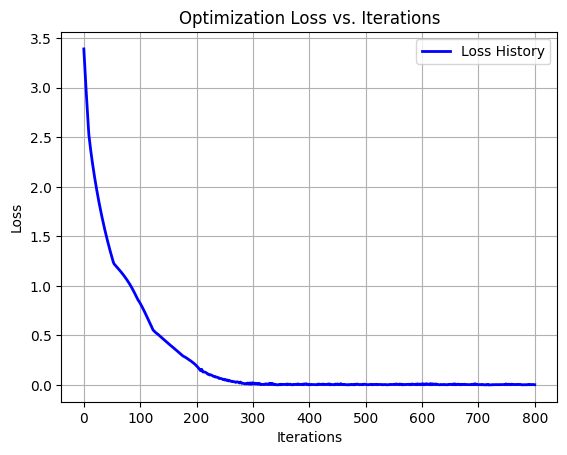

In [15]:
########## Differentiable FDM

# px = torch.zeros(len(f_n), 1, dtype=torch.float32)
px = torch.zeros(len(f_n), 1, dtype=torch.float32)
py = torch.zeros(len(f_n), 1, dtype=torch.float32)
pz = torch.zeros(len(f_n), 1, dtype=torch.float32)

for i, node in enumerate(f_n):
    if f_type[i] == 0:
        px[i] = F_value[i]
    elif f_type[i] == 1:
        py[i] = F_value[i]
    elif f_type[i] == 2:
        pz[i] = F_value[i]


## Obtaining Matrix D
# Assembly the nodal-branch matrix:
idx_CF = idx_Fixed
idx_CN = idx_Free
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1
CF = C[:, idx_CF]
CN = C[:, idx_CN]


# Assembly D
def FDM (Q, C=C, CN=CN, CF=CF, px=px, py=py, pz=pz,Fixed_nodes=Fixed_nodes, Free_nodes=Free_nodes,node_coords=grid_points) :
    Dn = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CN))
    DF = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CF))
    ## Coordinates solution
    # separate the coordinates:
    fixed_idces = [node - 1 for node in Fixed_nodes]
    xF = node_coords[fixed_idces, 0].unsqueeze(1)
    yF = node_coords[fixed_idces, 1].unsqueeze(1)
    zF = node_coords[fixed_idces, 2].unsqueeze(1)
    xN = torch.matmul(torch.inverse(Dn), (px - torch.matmul(DF, xF)))
    yN = torch.matmul(torch.inverse(Dn), (py - torch.matmul(DF, yF)))
    zN = torch.matmul(torch.inverse(Dn), (pz - torch.matmul(DF, zF)))
    ## Coordinates renewal: 
    new_node_coords = node_coords.clone()
    for idx, node in enumerate(Free_nodes):
        node_idx = node - 1
        new_node_coords[node_idx, 0] = xN[idx]
        new_node_coords[node_idx, 1] = yN[idx]
        new_node_coords[node_idx, 2] = zN[idx]
    print(new_node_coords[:,0])
    return new_node_coords





####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])


# ### Defining the OBJ:
# Obj_coords = torch.full((len(Free_nodes),), 12)



def Loss(Free_nodes, new_node_coords, Obj_coords):
    n_free_nodes = len(Free_nodes)
    Free_nodes = torch.tensor(Free_nodes)
    y_pred = new_node_coords[(Free_nodes - 1), 2]  
    y_true = Obj_coords 
    error = torch.abs(y_true - y_pred)
    loss = torch.mean(error)
    return loss


# Optimized Variables
## initial variables
n_elem = len(idx_X) + len(idx_Y)
q = torch.rand(n_elem, requires_grad=True)
## Optimization
torch.autograd.set_detect_anomaly(True)
optimizer = optim.Adam([q], lr=step)
# Loop start
Loss_his = []
for iteration in range(epochs + 1):
    print(iteration)
    # Forwards
    q_vec = torch.zeros(n_elements, requires_grad=True).clone()
    for i in range(len(idx_X)):
        q_vec[idx_X[i,:]] = q[i] 
    for j in range(len(idx_Y)):
        q_vec[idx_Y[j,:]] = q[j+len(idx_X)]  
    Q = torch.diag(q_vec) * 1 / r  # scaling
    new_node_coords = FDM(Q)
    # loss
    Loss_value = Loss(Free_nodes, new_node_coords, Obj_coords)
    Loss_his.append(Loss_value.item())
    # Backwards
    optimizer.zero_grad()
    # print(q.grad)
    Loss_value.backward(retain_graph=True)

    # Grad
    gradients = q.grad
    # print(gradients)
    frob_norm = torch.norm(gradients)
    
    # Step
    optimizer.step()
#   print(gradients)
# #     mean_error = torch.mean(error)
#     for i in range(len(q)):
#         if error[i] > 2 * mean_error:
#             q[i].data -= 5 * step * q.grad[i] 
#         else:
#             q[i].data -= step * q.grad[i]
    # print(new_node_coords)
    # print iteration
    if iteration % 5 == 0:
        print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")
print("Optimization completed.")
print(q)
print(new_node_coords)


#############################################################################################################
x_orig = grid_points[:, 0].detach().numpy()
y_orig = grid_points[:, 1].detach().numpy()
z_orig = grid_points[:, 2].detach().numpy()

x_def = new_node_coords[:, 0].detach().numpy()
y_def = new_node_coords[:, 1].detach().numpy()
z_def = new_node_coords[:, 2].detach().numpy()

fig = go.Figure()

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Original Geometry'
    ))

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FDM Solution'
    ))

for node in Free_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_def[node-1]],
        y=[y_def[node-1]],
        z=[z_def[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='green'),
        text=[f'Node {node}'],
        textposition='top center',
        name=f'Free Node {node}'
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Original vs. FDM',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.write_html("Go_figure_FDM.html")

# Plot loss history
plt.figure()
plt.plot(range(epochs + 1), Loss_his, label='Loss History', color='blue', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Optimization Loss vs. Iterations')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print(Obj_coords)

tensor([ 5.8776,  9.7959, 11.7551, 11.7551,  9.7959,  5.8776,  4.7398,  7.8996,
         9.4795,  9.4795,  7.8996,  4.7398,  3.8864,  6.4774,  7.7729,  7.7729,
         6.4774,  3.8864,  3.3176,  5.5293,  6.6351,  6.6351,  5.5293,  3.3176,
         3.0331,  5.0552,  6.0662,  6.0662,  5.0552,  3.0331,  3.0331,  5.0552,
         6.0662,  6.0662,  5.0552,  3.0331,  3.3176,  5.5293,  6.6351,  6.6351,
         5.5293,  3.3176,  3.8864,  6.4774,  7.7729,  7.7729,  6.4774,  3.8864,
         4.7398,  7.8996,  9.4795,  9.4795,  7.8996,  4.7398,  5.8776,  9.7959,
        11.7551, 11.7551,  9.7959,  5.8776])


In [ ]:
# ##### TNA reverse-q finding

# x = new_coords_db[:, 0]
# y = new_coords_db[:, 1]
# z = new_coords_db[:, 2]

# n_elements = len(connectivity)
# n_nodes = len(new_coords_db)
# C = torch.zeros(n_elements, n_nodes, dtype=torch.float32)
# for n, (i, j) in enumerate(connectivity):
#     C[n, i - 1] = 1
#     C[n, j - 1] = -1

# # 分解连接矩阵
# CF = C[:, idx_Free]  # 自由节点部分
# CN = C[:, idx_Fixed]  # 固定节点部分

# # 提取自由节点和固定节点的 z 坐标
# z_F = z[idx_Free]  # 自由节点的 z 坐标
# z_N = z[idx_Fixed]  # 固定节点的 z 坐标

# # 构建力平衡方程
# d = CF @ z_F + CN @ z_N  # d = C_F z_F + C_N z_N
# A = CF.T @ torch.diag(d)  # A = C_F^T diag(d)

# print(A.shape)
# Free_nodes = torch.tensor(Free_nodes)
# idx = (Free_nodes - 1)*6 + 2
# F_z = F[idx]
# print(idx)
# print(F_z.shape) 
# # 求解力密度 q
# q_TNA = torch.linalg.lstsq(A, F_z).solution

# print("力密度 q:", q_TNA)
# print(len(q))

In [89]:
# ## FDM Validation

# Q_T = torch.diag(q_TNA)  
# new_node_coords = FDM(Q_T)
# print(new_node_coords)
# # 绘图
# x_orig = grid_points[:, 0].detach().numpy()
# y_orig = grid_points[:, 1].detach().numpy()
# z_orig = grid_points[:, 2].detach().numpy()

# x_def = grid_points[:, 0].detach().numpy()
# y_def = grid_points[:, 1].detach().numpy()
# z_def = new_node_coords[:, 2].detach().numpy()

# fig = go.Figure()

# # 绘制原始网格
# for connection in connectivity:
#     i, j = connection
#     fig.add_trace(go.Scatter3d(
#         x=[x_orig[i-1], x_orig[j-1]],
#         y=[y_orig[i-1], y_orig[j-1]],
#         z=[z_orig[i-1], z_orig[j-1]],
#         mode='lines',
#         line=dict(color='blue', width=4),
#         name='Original Geometry'
#     ))

# # 绘制 FDM 找形后的网格
# for connection in connectivity:
#     i, j = connection
#     fig.add_trace(go.Scatter3d(
#         x=[x_def[i-1], x_def[j-1]],
#         y=[y_def[i-1], y_def[j-1]],
#         z=[z_def[i-1], z_def[j-1]],
#         mode='lines',
#         line=dict(color='red', width=4),
#         name='FDM Solution'
#     ))

# # 标注自由节点
# for node in idx_Free:
#     fig.add_trace(go.Scatter3d(
#         x=[x_def[node-1]],
#         y=[y_def[node-1]],
#         z=[z_def[node-1]],
#         mode='markers+text',
#         marker=dict(size=5, color='green'),
#         text=[f'Node {node}'],
#         textposition='top center',
#         name=f'Free Node {node}'
#     ))

# # 更新布局
# fig.update_layout(
#     scene=dict(
#         xaxis_title='X',
#         yaxis_title='Y',
#         zaxis_title='Z',
#         aspectmode='data'
#     ),
#     title='Original vs. FDM',
#     legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
# )

# # 保存为 HTML 文件
# fig.write_html("Vali_FDM.html")
# print('complete')

tensor([  0.0000,   8.1485,  15.0648,  18.9897,  18.9897,  15.0648,   8.1485,
          0.0000,   4.8000,   2.5673,   0.8306,   1.0041,   1.0041,   0.8306,
          2.5673,   4.8000,   9.6000,   3.0710,  -4.7265, -11.9630, -11.9630,
         -4.7265,   3.0710,   9.6000,  14.4000,  20.9290,  28.7265,  35.9630,
         35.9630,  28.7265,  20.9290,  14.4000,  19.2000,  21.4327,  23.1694,
         22.9959,  22.9959,  23.1694,  21.4327,  19.2000,  24.0000,  15.8515,
          8.9352,   5.0103,   5.0103,   8.9352,  15.8514,  24.0000])
tensor([[  0.0000,  24.0000,   0.0000],
        [  8.1485,  24.0000,   5.8775],
        [ 15.0648,  24.0000,   9.7959],
        [ 18.9897,  24.0000,  11.7551],
        [ 18.9897,   0.0000,  11.7551],
        [ 15.0648,   0.0000,   9.7959],
        [  8.1485,   0.0000,   5.8775],
        [  0.0000,   0.0000,   0.0000],
        [  4.8000,  24.0000,   0.0000],
        [  2.5673,  24.0000,   4.0344],
        [  0.8306,  24.0000,   6.7239],
        [  1.0041,  24.